In [1]:
import xgboost as xgb
import pandas as pd
from sklearn.preprocessing import StandardScaler

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import site_archive_nci

import shap

In [2]:
model = xgb.XGBRegressor()
model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")

In [3]:
data = pd.read_csv('/scratch/er8/cd3022/xgb_datasets/test_data.csv').set_index('time')

In [4]:
X = data.drop(columns=['surface_global_irradiance_t1'])
# for n in range(2, 11):
#     X = X.drop(columns=[f'surface_global_irradiance_t{n}'])

# Remove satellite GHI to investigate other variables more closely
# X = data.drop(columns=['surface_global_irradiance_t1', 'surface_global_irradiance'])
y = data['surface_global_irradiance_t1']

In [5]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# # Convert back to DataFrame (keeps column names)
# X_scaled = pd.DataFrame(X_scaled, columns=data.columns, index=data.index)

In [6]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train_scaled)

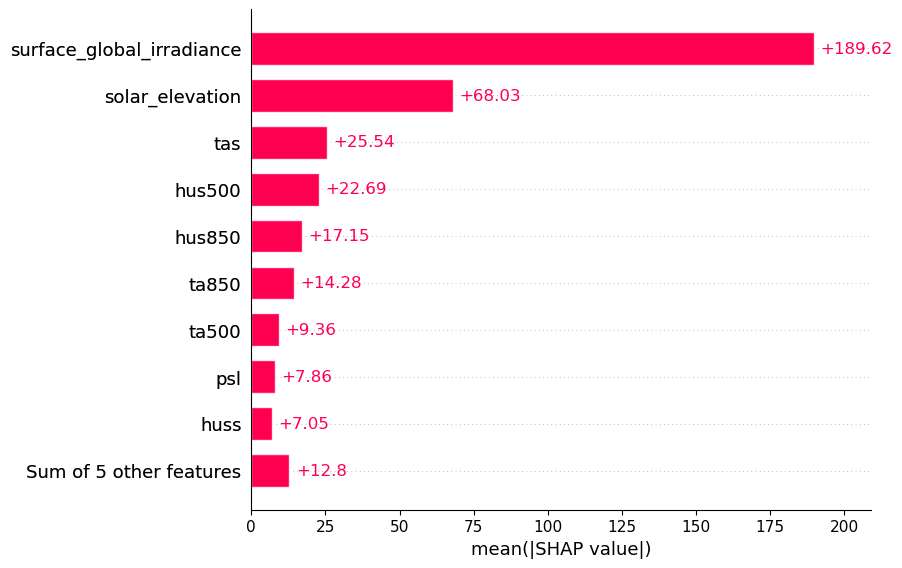

In [8]:
shap.plots.bar(shap_values)

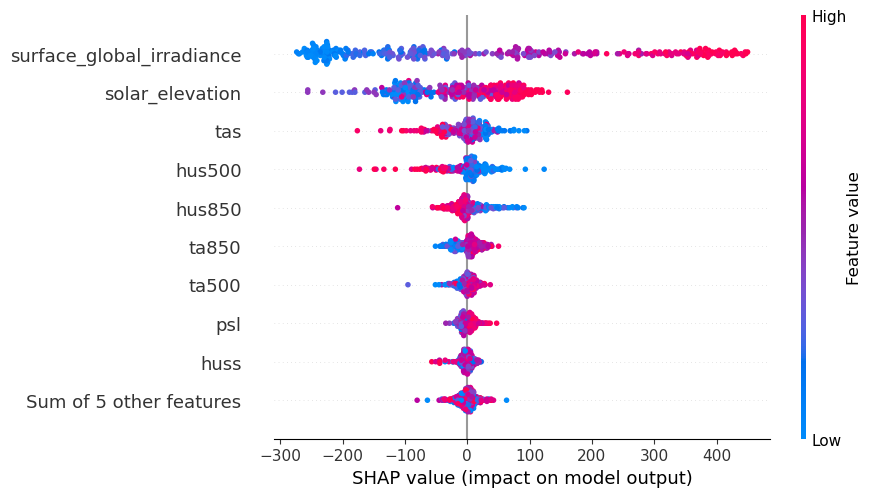

In [9]:
shap.plots.beeswarm(shap_values)

In [10]:
himawari = petdata.archive.Himawari(
    [
    'surface_global_irradiance',
    'solar_elevation'
    ]
)

variables_of_interest = [
    'huss',
    'hus850',
    'hus700',
    'hus500',
    'psl',
    'tas',
    'ta850',
    'ta700',
    'ta500',
    # 'rsds',
]
frequency = '1hr'
domain_id = 'AUST-04'
barra = petdata.archive.BARRA_V2(
    variables_of_interest,
    frequency=frequency,
    domain_id=domain_id
)

# Spatial Analysis

In [11]:
satpipe = petpipe.Pipeline(
    himawari,
    petdata.transform.region.Bounding(min_lat=-34.0, max_lat = -33.8, min_lon=151.0, max_lon=151.2),
    iterator=petpipe.iterators.DateRange('20240101T00', '20240201T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

barpipe = petpipe.Pipeline(
    barra,
    petdata.transform.region.Bounding(min_lat=-34.0, max_lat = -33.8, min_lon=151.0, max_lon=151.2),
    petdata.transform.region.ISelect(height=0),
    iterator=petpipe.iterators.DateRange('20240101T00', '20240201T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

ds_him = satpipe['2024-02-01']
ds_bar = barpipe['2024-02-01']

/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:326: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  full_ds = xr.open_mfdataset(
/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:209: IndexWarning: Unable to subset on time dimension, returning all timesteps for validation. For request: 2024-02-01T00:00 -> 2024-02-02T00:00 @ 0 days 00:10:00
  warnings.warn(
/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:326: FutureWarning: In a future version of xarray the default value for compat will change from com

In [12]:
ds_bar = ds_bar.interp(
    latitude=ds_him.latitude,
    longitude=ds_him.longitude,
    method='nearest'
)